In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

# Ensure we can import from src directory
import sys
import os
if os.path.join(os.getcwd(), 'src') not in sys.path:
    sys.path.append(os.path.join(os.getcwd(), 'src'))


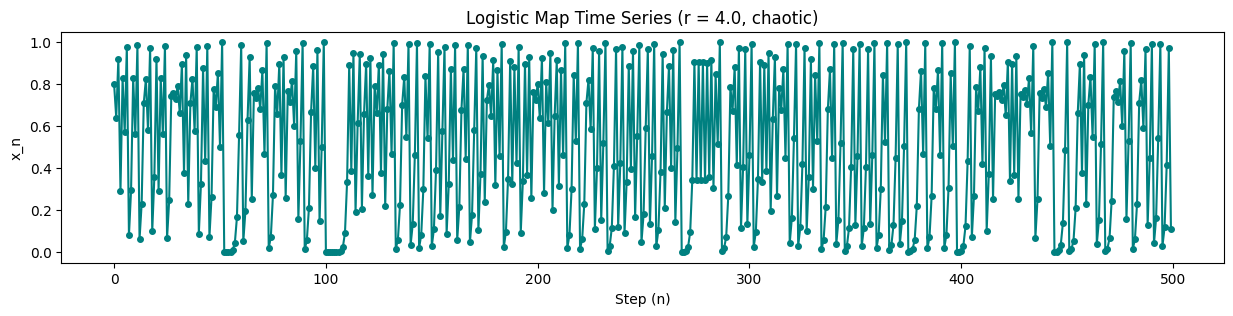

Lyapunov Spectrum: [0.69315]


In [7]:
from le_calc.maps import LogisticMap

# Initialize Logistic Map (default r = 4.0, chaotic)
model = LogisticMap()
x0=0.65
model.simulate(x0,n_steps=50000)

# Plot the time series iteration
fig, ax2 = plt.subplots(figsize=(15, 3))
ax2.plot(model.x[:500], marker='o', markersize=4, linestyle='-', color='teal')
ax2.set_title("Logistic Map Time Series (r = 4.0, chaotic)")
ax2.set_xlabel("Step (n)")
ax2.set_ylabel("x_n")
plt.show()

# calculating Lyapunov exponents
model.discrete_qr_lyapunov_spectrum()


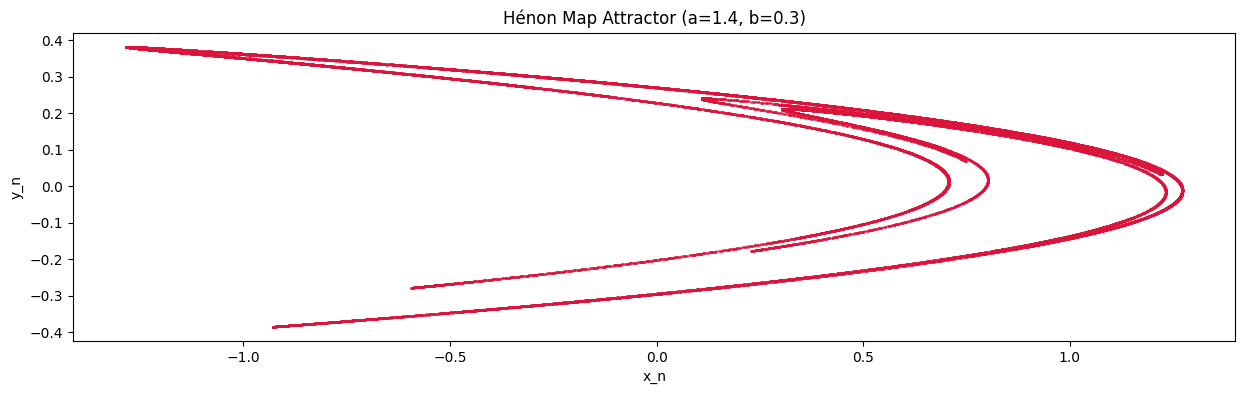

Lyapunov Spectrum: [0.41862 -1.62260]


In [8]:
from le_calc.maps import HenonMap

# Initialize chaotic Hénon Map (default a=1.4, b=0.3)
model = HenonMap()
x0 = [0.5, 0.2]  
model.simulate(x0, n_steps=50000)

# Plot the Hénon attractor as a scatter plot
fig, ax3 = plt.subplots(figsize=(15, 4))
ax3.scatter(model.x[:,0], model.x[:,1], s=0.5, color='crimson', alpha=0.5)
ax3.set_title('Hénon Map Attractor (a=1.4, b=0.3)')
ax3.set_xlabel('x_n')
ax3.set_ylabel('y_n')
plt.show()

# calculating Lyapunov exponents
model.discrete_qr_lyapunov_spectrum()


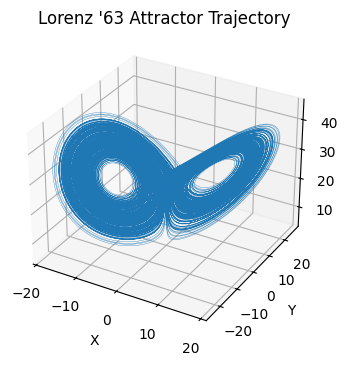

In [ ]:
from le_calc.odes import Lorenz63
from le_calc.utils import integrate

# Initialize Lorenz system
model = Lorenz63()

# Define initial conditions and time span
x0 = [1.0, 1.0, 10.0]
dim = len(x0)
Phi0 = np.eye(dim)
t_span = (50, 350)
delta_t = 0.005
n_steps = int((t_span[1]-t_span[0])/delta_t)

# integrate discarding transients
x_history,Phi,Q_history,R_history = integrate(model, delta_t, t_span,x0,Phi0)
# x_history = integrate(model, delta_t, t_span,x0)

# Plot the trajectory in 3D
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_history[:,0],x_history[:,1],x_history[:,2], lw=0.25)
ax.set_title("Lorenz '63 Attractor Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

In [75]:
from scipy.linalg import expm

logR_history = np.zeros((n_steps,dim))
for i in range(n_steps):
    Q,R = np.linalg.qr(Phi[i])
    logR_history[i] = np.log(np.abs(np.diag(R)))
print(f"Discrete QR every step, QR on Phi: {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:+.5f}'})}")

logR_history = np.zeros((n_steps,dim))
for i in range(n_steps):
    logR_history[i] = np.log(np.abs(np.diag(R_history[i])))
print(f"Discrete QR every step, Saving R : {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:+.5f}'})}")

Q = np.eye(dim)
logR_history = np.zeros((n_steps,dim))
for i in range(n_steps):
    Q,R = np.linalg.qr(expm(delta_t*model.jac(x_history[i]))@Q)
    logR_history[i] = np.log(np.abs(np.diag(R)))
print(f"Discrete QR Matrix Exponential   : {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:+.5f}'})}")

def integrator(x):
    return np.eye(dim)+delta_t*model.jac(x)

Q = np.eye(dim)
logR_history = np.zeros((n_steps,dim))
for i in range(n_steps):
    Q,R = np.linalg.qr(integrator(x_history[i])@Q)
    logR_history[i] = np.log(np.abs(np.diag(R)))
print(f"Discrete QR Random Integrator    : {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:+.5f}'})}")

local_lyap = np.ones(x_history.shape)
for i in range(n_steps):
    local_lyap[i] = np.diag(Q_history[i].T@model.jac(x_history[i])@Q_history[i])
print(f"Continuous QR                    : {np.array2string(np.mean(local_lyap,axis=0), formatter={'float_kind':lambda x: f'{x:+.5f}'})}")

Discrete QR every step, QR on Phi: [+0.90264 +0.00224 -14.57154]
Discrete QR every step, Saving R : [+0.90264 +0.00224 -14.57154]
Discrete QR Matrix Exponential   : [+0.90258 +0.00220 -14.57146]
Discrete QR Random Integrator    : [+1.07931 +0.22762 -15.18685]
Continuous QR                    : [+0.91266 -0.00114 -14.57818]


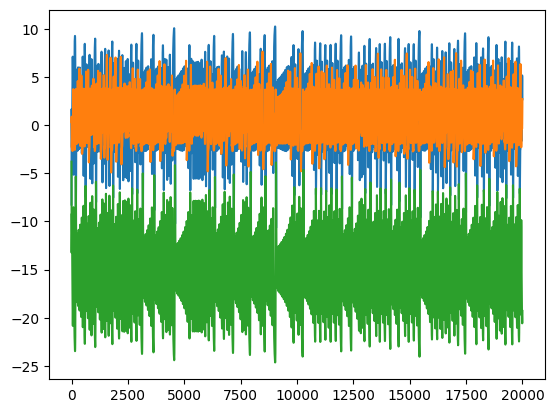

Lyapunov Spectrum: [1.18450 0.51859 -15.87599]


In [165]:
dim = 3
Q = np.eye(dim)
logR_history = np.zeros((n_steps,dim))

for i in range(n_steps):
    Q,R = np.linalg.qr((np.eye(dim)+delta_t*model.jac(x_history[i]))@Q)
    logR_history[i] = np.log(np.abs(np.diag(R)))
    
plt.plot(logR_history/delta_t)
plt.show()
print(f"Lyapunov Spectrum: {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:.5f}'})}")

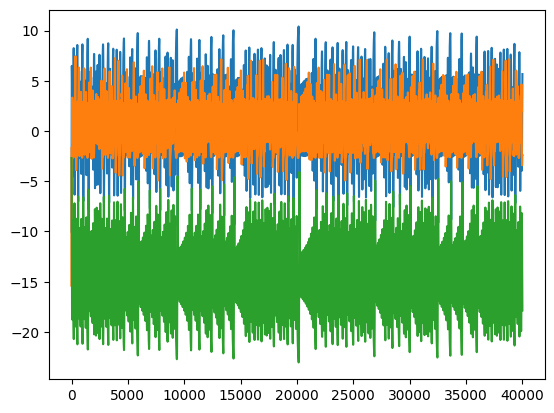

Lyapunov Spectrum: [1.06952 0.23024 -15.17827]


In [43]:
dim = 3
Q = np.eye(dim)
logR_history = np.zeros((n_steps,dim))

for i in range(n_steps):
    Q,R = np.linalg.qr((np.eye(dim)+delta_t*model.jac(x_history[i]))@Q)
    logR_history[i] = np.log(np.abs(np.diag(R)))
    
plt.plot(logR_history/delta_t)
plt.show()
print(f"Lyapunov Spectrum: {np.array2string(np.mean(logR_history[1000:],axis=0)/delta_t, formatter={'float_kind':lambda x: f'{x:.5f}'})}")